# TSLA 주가 데이터, RNN 모델을 이용한 주가예측

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

# =========================
# 1. 데이터 로드
# =========================

df = pd.read_csv("../data/TSLA.csv")

print(df.head())
print(df.columns)

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')


In [3]:
# =========================
# 2. Open 가격만 사용
# 다른 컬럼은 사용하지 않음
# =========================

data = df[["Open"]]

print(data.head())
print(data.shape)


    Open
0  3.800
1  5.158
2  5.000
3  4.600
4  4.000
(2956, 1)


In [4]:
# =========================
# 3. Train / Test 분리
# 시계열 데이터라 섞지 않고 앞 80%, 뒤 20% 사용
# =========================

split = int(len(data) * 0.8)

train_data = data.iloc[:split]
test_data = data.iloc[split:]

print("train_data:", train_data.shape)
print("test_data:", test_data.shape)

train_data: (2364, 1)
test_data: (592, 1)


In [5]:
# =========================
# 4. 정규화
# train 기준으로 fit
# test는 transform만 함
# =========================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [6]:
# =========================
# 5. (시퀀스)순환 데이터 생성 함수
# 과거 window일 Open 가격 -> 다음 날 Open 가격 예측
# =========================

def make_sequence(data, window):
    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])

    return np.array(X), np.array(y)

window = 30

X_train, y_train = make_sequence(train_scaled, window)
X_test, y_test = make_sequence(test_scaled, window)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2334, 30, 1)
y_train: (2334, 1)
X_test: (562, 30, 1)
y_test: (562, 1)


In [7]:
# =========================
# 6. RNN 모델 생성
# 뉴런 수 조정 가능: 32, 64, 128 등
# =========================

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(
        128,
        input_shape=(window, 1)
    ),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/Users/ganghyejun/Desktop/100_College/2-1/인공지능개론/AICLASS_2-1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================
# 7. 학습
# =========================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0043 - mae: 0.0327 - val_loss: 0.0019 - val_mae: 0.0335
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.8449e-04 - mae: 0.0163 - val_loss: 0.0015 - val_mae: 0.0295
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8846e-04 - mae: 0.0164 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8095e-04 - mae: 0.0147 - val_loss: 0.0016 - val_mae: 0.0306
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9284e-04 - mae: 0.0128 - val_loss: 0.0013 - val_mae: 0.0265
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7736e-04 - mae: 0.0126 - val_loss: 0.0011 - val_mae: 0.0245
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7640e-04 - mae: 0.0145 - val_loss: 0.0011 - val_mae: 0.0252
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6663e-04 - mae: 0.0126 - val_loss: 0.0011 - val_mae: 0.0249
Epoch 9/50
117/117 ━━━━━━━━━

In [27]:
# =========================
# 8. 평가
# =========================

loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 26.2581 - mae: 4.0182
Test Loss: 26.25814437866211
Test MAE: 4.018182754516602


In [9]:
# =========================
# 9. 예측
# =========================

pred = model.predict(X_test)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [10]:
# =========================
# 10. 정규화 복원
# =========================

y_test_real = scaler.inverse_transform(y_test)
pred_real = scaler.inverse_transform(pred)


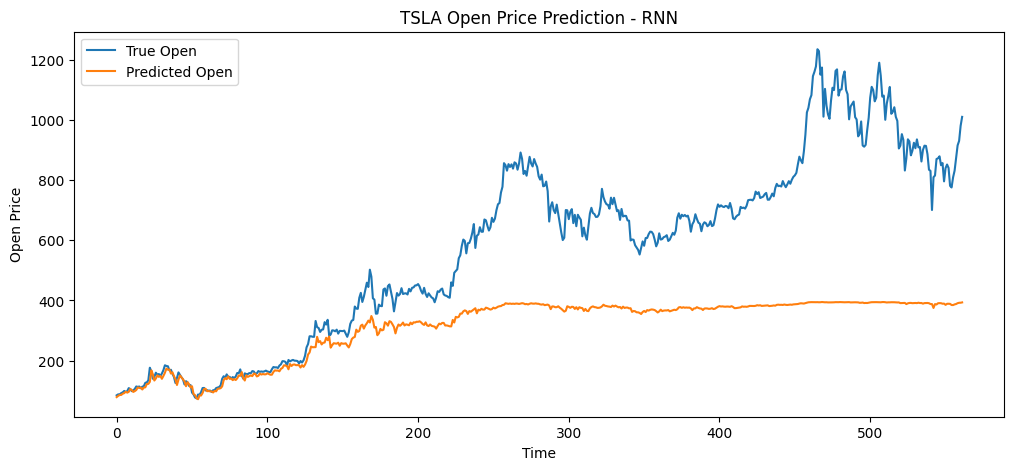

In [11]:
# =========================
# 11. 실제값 vs 예측값 시각화
# =========================

plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label="True Open")
plt.plot(pred_real, label="Predicted Open")
plt.title("TSLA Open Price Prediction - RNN")
plt.xlabel("Time")
plt.ylabel("Open Price")
plt.legend()
plt.show()